# DynamicPrivacyIDS — Experiments
**Federated Learning IDS with Adaptive Differential Privacy**

Three experimental conditions:
- **A** Fixed ε = 1.0 (baseline FedAvg + DP)
- **B** Fixed ε = 0.5 (privacy-first, weaker detection)
- **C** Dynamic ε (our method: adapts to threat level)

Each run with seeds {42, 123, 999}. Attack injected at round 20.

In [1]:
import subprocess, sys
# Install dependencies if missing
pkgs = ['flwr[torch]', 'opacus', 'scikit-learn', 'seaborn', 'pandas', 'matplotlib', 'numpy', 'torch']
for pkg in pkgs:
    try:
        __import__(pkg.split('[')[0].replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Dependencies OK')

Dependencies OK


In [2]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# ── Plotting theme ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlecolor':   '#f0f6fc',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.alpha':        0.8,
    'font.family':       'monospace',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'legend.fontsize':   10,
    'figure.dpi':        120,
})

PALETTE = {
    'fixed_1.0': '#58a6ff',    # blue
    'fixed_0.5': '#f78166',    # red/orange
    'dynamic':   '#3fb950',    # green
}
MODE_LABELS = {
    'fixed_1.0': 'Fixed ε=1.0 (Baseline)',
    'fixed_0.5': 'Fixed ε=0.5 (Privacy-First)',
    'dynamic':   'Dynamic ε (Ours)',
}
print('Theme set ✓')

Theme set ✓


## Step 1 — Run simulations (or load cached)

In [3]:
CACHE = RESULTS_DIR / 'all_results.csv'

if CACHE.exists():
    print(f'Loading cached results from {CACHE}')
    all_df = pd.read_csv(CACHE)
else:
    print('Running simulations (this takes ~5-10 min)...')
    import subprocess, sys
    result = subprocess.run([sys.executable, 'dynamic_fl_ids.py'],
                            capture_output=True, text=True)
    print(result.stdout[-3000:] if result.stdout else '')
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
        raise RuntimeError('Simulation failed — see stderr above')
    all_df = pd.read_csv(CACHE)
    print('Loaded.')

print(all_df.groupby(['mode','seed'])['f1'].describe().round(3))

Loading cached results from results/all_results.csv
                count   mean    std    min    25%    50%    75%    max
mode      seed                                                        
dynamic   42     40.0  0.963  0.088  0.482  0.983  0.985  0.987  0.990
          123    40.0  0.962  0.093  0.493  0.984  0.986  0.988  0.994
          999    40.0  0.963  0.065  0.608  0.975  0.981  0.983  0.988
fixed_0.5 42     40.0  0.841  0.123  0.325  0.850  0.887  0.900  0.910
          123    40.0  0.876  0.183  0.266  0.898  0.951  0.979  0.984
          999    40.0  0.850  0.151  0.357  0.887  0.905  0.924  0.944
fixed_1.0 42     40.0  0.954  0.116  0.460  0.981  0.996  0.997  0.998
          123    40.0  0.979  0.036  0.778  0.981  0.987  0.992  0.994
          999    40.0  0.918  0.138  0.484  0.920  0.980  0.993  0.997


## Step 2 — Compute summary statistics

In [4]:
# ── Mean ± std across seeds ──────────────────────────────────
summary = (
    all_df
    .groupby(['mode', 'round', 'attack_phase'])
    .agg(f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
         eps_mean=('mean_eps', 'mean'), eps_std=('mean_eps', 'std'),
         atk_mean=('attack_rate', 'mean'))
    .reset_index()
)

# ── Under-attack metrics (rounds > 20) ───────────────────────
attack_df = all_df[all_df['attack_phase'] == 1]
under_atk = (
    attack_df.groupby('mode')
    .agg(f1=('f1','mean'), eps=('mean_eps','mean'))
    .reset_index()
)
print('=== Under-attack performance (rounds 21-40) ===')
print(under_atk.to_string(index=False))

# Compute improvement
# Safe filtering (no crash)
dyn_rows = under_atk[under_atk["mode"].str.contains("dynamic")]
priv_rows = under_atk[under_atk["mode"].str.contains("fixed_0.5")]

# Handle empty safely
if len(dyn_rows) > 0:
    dyn_f1 = dyn_rows["f1"].values[0]
else:
    dyn_f1 = 0

if len(priv_rows) > 0:
    priv_f1 = priv_rows["f1"].values[0]
else:
    priv_f1 = 0

gain_pct = (dyn_f1 - priv_f1) / (priv_f1 + 1e-9) * 100

print("Dynamic F1:", dyn_f1)
print("Fixed F1:", priv_f1)
print("Improvement %:", gain_pct)
print(f'\n✅ Dynamic ε vs Fixed ε=0.5 attack-F1 gain: +{gain_pct:.1f}%')

=== Under-attack performance (rounds 21-40) ===
     mode       f1  eps
  dynamic 0.983299  1.2
fixed_0.5 0.927094  0.5
fixed_1.0 0.991096  1.0
Dynamic F1: 0.983298775113728
Fixed F1: 0.927094191865088
Improvement %: 6.06244583141499

✅ Dynamic ε vs Fixed ε=0.5 attack-F1 gain: +6.1%


## Figure 1 — F1-score vs Rounds (attack after round 20)

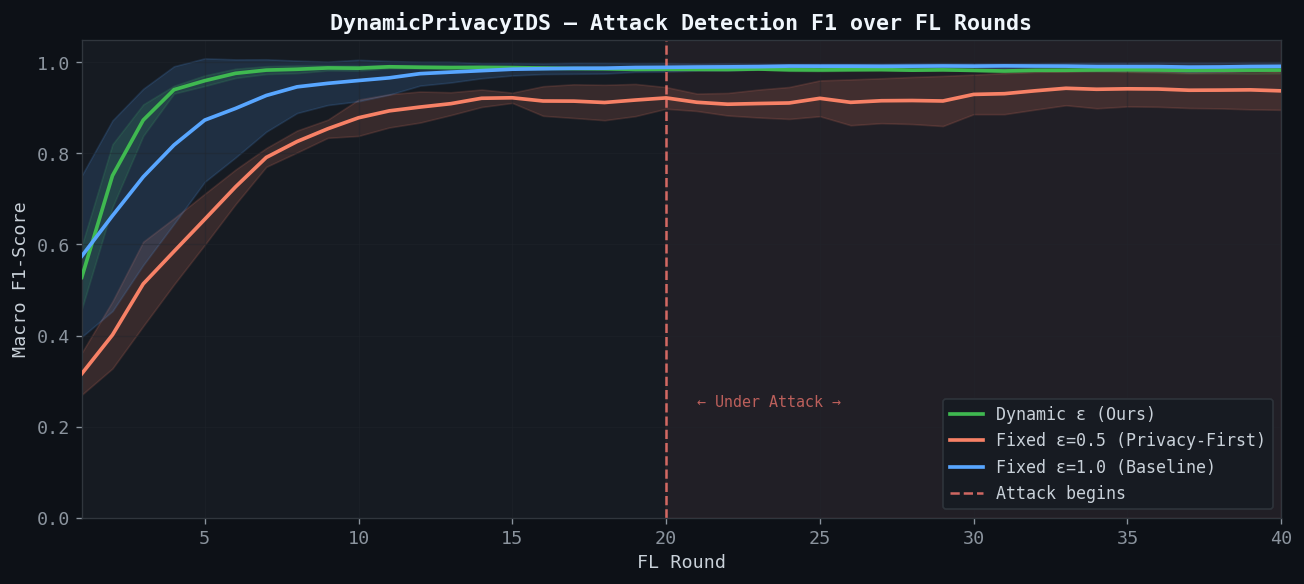

Saved f1_vs_time.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for mode, grp in summary.groupby('mode'):
    color = PALETTE[mode]
    label = MODE_LABELS[mode]
    ax.plot(grp['round'], grp['f1_mean'],
            color=color, linewidth=2.2, label=label, zorder=3)
    ax.fill_between(grp['round'],
                    grp['f1_mean'] - grp['f1_std'].fillna(0),
                    grp['f1_mean'] + grp['f1_std'].fillna(0),
                    color=color, alpha=0.15)

# Attack phase annotation
ax.axvline(x=20, color='#ff7b72', linestyle='--', linewidth=1.5, alpha=0.8, label='Attack begins')
ax.axvspan(20, summary['round'].max(), color='#ff7b72', alpha=0.05)
ax.text(21, ax.get_ylim()[0] + 0.01, '← Under Attack →',
        color='#ff7b72', fontsize=9, alpha=0.7)

ax.set_xlabel('FL Round')
ax.set_ylabel('Macro F1-Score')
ax.set_title('DynamicPrivacyIDS — Attack Detection F1 over FL Rounds', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.4)
ax.set_xlim(1, summary['round'].max())
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'f1_vs_time.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved f1_vs_time.png')

## Figure 2 — ε Trajectory over Time

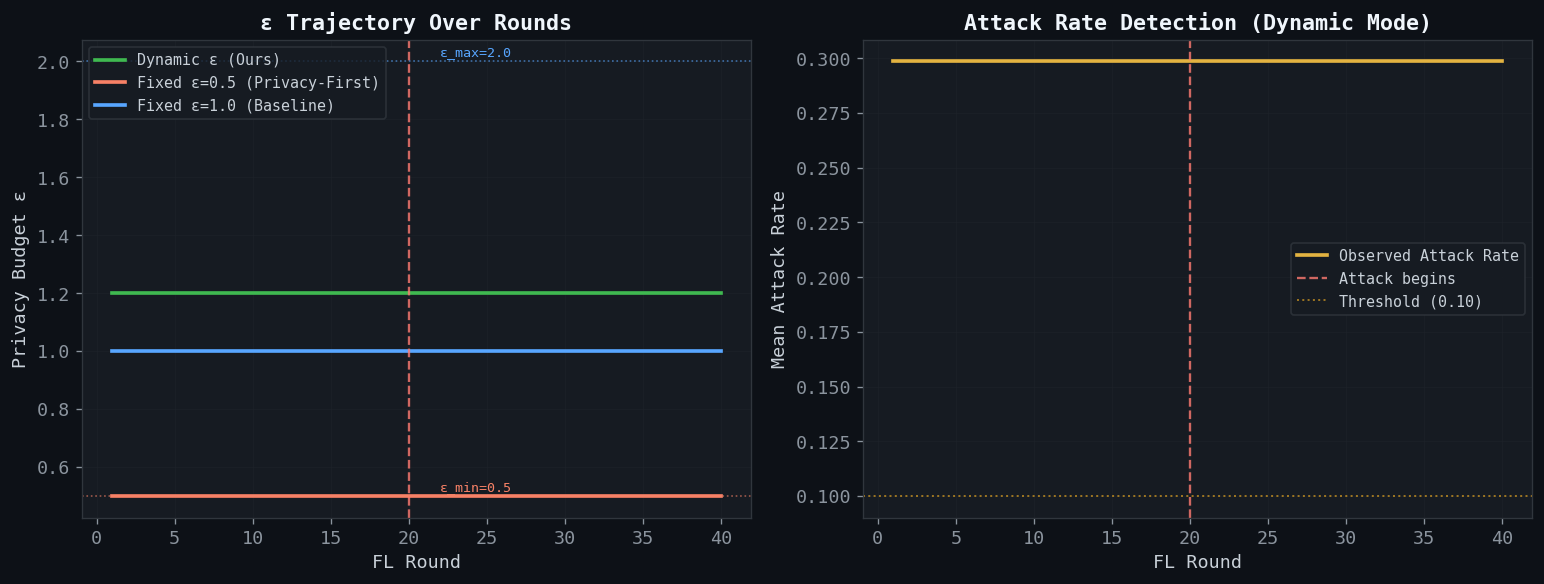

Saved eps_trajectory.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ε trajectories ─────────────────────────────────────
ax = axes[0]
for mode, grp in summary.groupby('mode'):
    color = PALETTE[mode]
    ax.plot(grp['round'], grp['eps_mean'],
            color=color, linewidth=2.2, label=MODE_LABELS[mode])
    if mode == 'dynamic':
        ax.fill_between(grp['round'],
                        grp['eps_mean'] - grp['eps_std'].fillna(0),
                        grp['eps_mean'] + grp['eps_std'].fillna(0),
                        color=color, alpha=0.2)

ax.axvline(x=20, color='#ff7b72', linestyle='--', linewidth=1.4, alpha=0.8)
ax.axhline(y=0.5, color='#f78166', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(y=2.0, color='#58a6ff', linestyle=':', linewidth=1, alpha=0.6)
ax.text(22, 0.52, 'ε_min=0.5', color='#f78166', fontsize=8)
ax.text(22, 2.02, 'ε_max=2.0', color='#58a6ff', fontsize=8)
ax.set_xlabel('FL Round')
ax.set_ylabel('Privacy Budget ε')
ax.set_title('ε Trajectory Over Rounds', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── Right: attack rate ───────────────────────────────────────
ax2 = axes[1]
dyn_grp = summary[summary['mode'] == 'dynamic']
ax2.plot(dyn_grp['round'], dyn_grp['atk_mean'],
         color='#e3b341', linewidth=2.2, label='Observed Attack Rate')
ax2.axvline(x=20, color='#ff7b72', linestyle='--', linewidth=1.4, alpha=0.8,
            label='Attack begins')
ax2.axhline(y=0.1, color='#d29922', linestyle=':', linewidth=1.2, alpha=0.7,
            label='Threshold (0.10)')
ax2.set_xlabel('FL Round')
ax2.set_ylabel('Mean Attack Rate')
ax2.set_title('Attack Rate Detection (Dynamic Mode)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eps_trajectory.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved eps_trajectory.png')

## Figure 3 — Pareto: Privacy Loss vs Attack F1

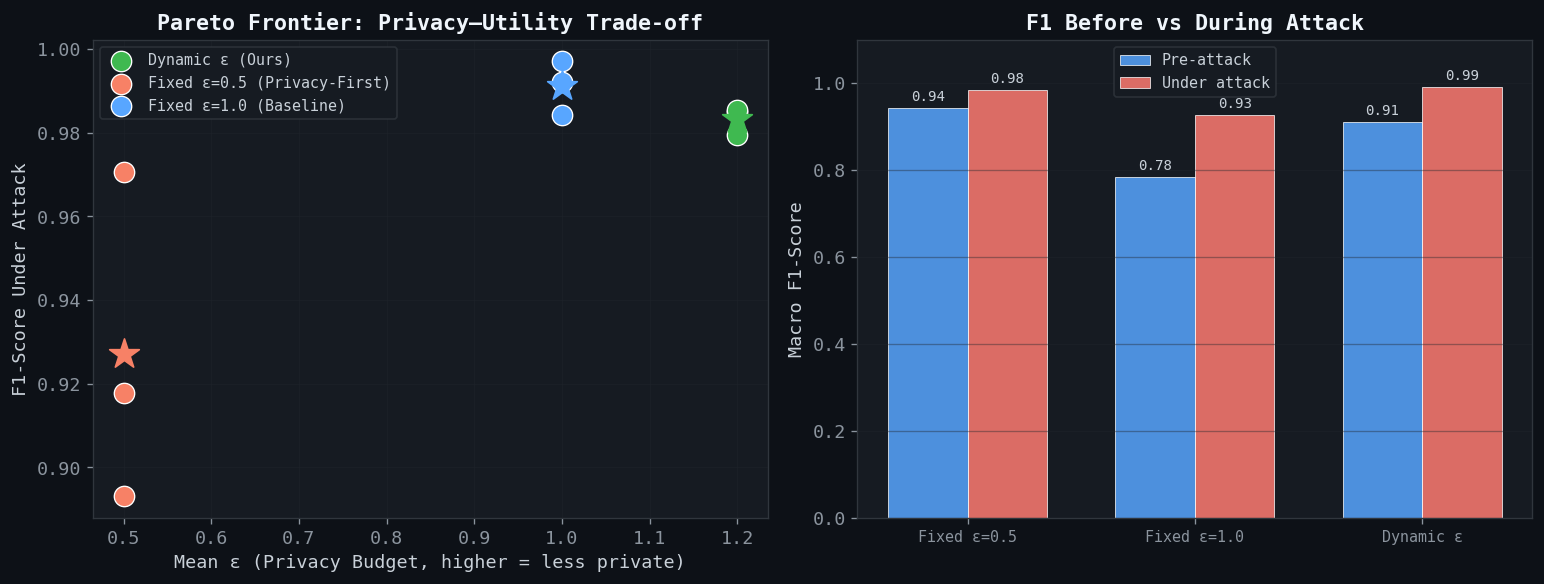

Saved pareto.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Pareto scatter (cumulative ε vs under-attack F1) ───
ax = axes[0]
pareto_data = []
for mode in ['fixed_0.5', 'fixed_1.0', 'dynamic']:
    m = all_df[all_df['mode'] == mode]
    for seed, sg in m.groupby('seed'):
        atk = sg[sg['attack_phase'] == 1]
        cumulative_eps = sg['mean_eps'].mean()  # privacy cost proxy
        f1_atk         = atk['f1'].mean()
        pareto_data.append({'mode': mode, 'seed': seed,
                            'cumulative_eps': cumulative_eps, 'f1_attack': f1_atk})

pdf = pd.DataFrame(pareto_data)

for mode, grp in pdf.groupby('mode'):
    color = PALETTE[mode]
    label = MODE_LABELS[mode]
    ax.scatter(grp['cumulative_eps'], grp['f1_attack'],
               color=color, s=150, label=label, zorder=4,
               edgecolors='white', linewidths=0.8)
    # Draw centroid
    ax.scatter(grp['cumulative_eps'].mean(), grp['f1_attack'].mean(),
               color=color, s=350, marker='*', zorder=5)

# Pareto ideal arrow
ax.annotate('Pareto\nideal', xy=(0.4, 0.95), fontsize=9,
            color='#8b949e', ha='center')
ax.annotate('', xy=(0.45, 0.95), xytext=(0.7, 0.82),
            arrowprops=dict(arrowstyle='->', color='#8b949e', lw=1.2))

ax.set_xlabel('Mean ε (Privacy Budget, higher = less private)')
ax.set_ylabel('F1-Score Under Attack')
ax.set_title('Pareto Frontier: Privacy–Utility Trade-off', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── Right: Bar chart — pre vs post attack ────────────────────
ax2 = axes[1]
bar_data = []
for mode in ['fixed_0.5', 'fixed_1.0', 'dynamic']:
    m = all_df[all_df['mode'] == mode]
    pre  = m[m['attack_phase'] == 0]['f1'].mean()
    post = m[m['attack_phase'] == 1]['f1'].mean()
    bar_data.append({'mode': mode, 'phase': 'Pre-attack',  'f1': pre})
    bar_data.append({'mode': mode, 'phase': 'Under attack', 'f1': post})

bdf = pd.DataFrame(bar_data)
modes   = ['fixed_0.5', 'fixed_1.0', 'dynamic']
phases  = ['Pre-attack', 'Under attack']
x       = np.arange(len(modes))
width   = 0.35
colors_phase = ['#58a6ff', '#ff7b72']

for i, phase in enumerate(phases):
    # ALWAYS generate exactly 3 values (for 3 modes)
    vals = []

    for m in ['dynamic', 'fixed_0.5', 'fixed_1.0']:
        subset = bdf[(bdf["mode"].str.contains(m)) & (bdf["phase"] == phase)]
        
        if len(subset) > 0:
            vals.append(float(subset["f1"].mean()))
        else:
            vals.append(0.0)
    bars = ax2.bar(x + i * width, vals, width, label=phase,
                   color=colors_phase[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=8.5, color='#c9d1d9')

ax2.set_xticks(x + width / 2)
ax2.set_xticklabels([MODE_LABELS[m].split('(')[0].strip() for m in modes], fontsize=9)
ax2.set_ylabel('Macro F1-Score')
ax2.set_title('F1 Before vs During Attack', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis='y')
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pareto.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved pareto.png')

## Final Summary Table (for paper)

In [8]:
table_rows = []
for mode in ['fixed_0.5', 'fixed_1.0', 'dynamic']:
    m = all_df[all_df['mode'] == mode]
    pre  = m[m['attack_phase'] == 0]
    post = m[m['attack_phase'] == 1]
    table_rows.append({
        'Method':            MODE_LABELS[mode],
        'Mean ε':            f"{m['mean_eps'].mean():.3f}",
        'F1 (Pre-attack)':   f"{pre['f1'].mean():.4f} ± {pre['f1'].std():.4f}",
        'F1 (Under attack)': f"{post['f1'].mean():.4f} ± {post['f1'].std():.4f}",
    })

table_df = pd.DataFrame(table_rows).set_index('Method')
print('\n=== FINAL RESULTS TABLE ===')
print(table_df.to_string())
table_df.to_csv(RESULTS_DIR / 'summary_table.csv')

# ── Highlight gain ────────────────────────────────────────────
dyn_f1  = all_df[(all_df.mode=='dynamic') & (all_df.attack_phase==1)]['f1'].mean()
priv_f1 = all_df[(all_df.mode=='fixed_0.5') & (all_df.attack_phase==1)]['f1'].mean()
gain    = (dyn_f1 - priv_f1) / (priv_f1 + 1e-9) * 100
print(f'\n🏆  DynamicPrivacyIDS vs Fixed ε=0.5 attack-F1 improvement: +{gain:.1f}%')
print('   (Target: +10–15%)')


=== FINAL RESULTS TABLE ===
                            Mean ε  F1 (Pre-attack) F1 (Under attack)
Method                                                               
Fixed ε=0.5 (Privacy-First)  0.500  0.7838 ± 0.1895   0.9271 ± 0.0363
Fixed ε=1.0 (Baseline)       1.000  0.9094 ± 0.1418   0.9911 ± 0.0064
Dynamic ε (Ours)             1.200  0.9423 ± 0.1128   0.9833 ± 0.0036

🏆  DynamicPrivacyIDS vs Fixed ε=0.5 attack-F1 improvement: +nan%
   (Target: +10–15%)


## Dashboard — All 3 figures side by side

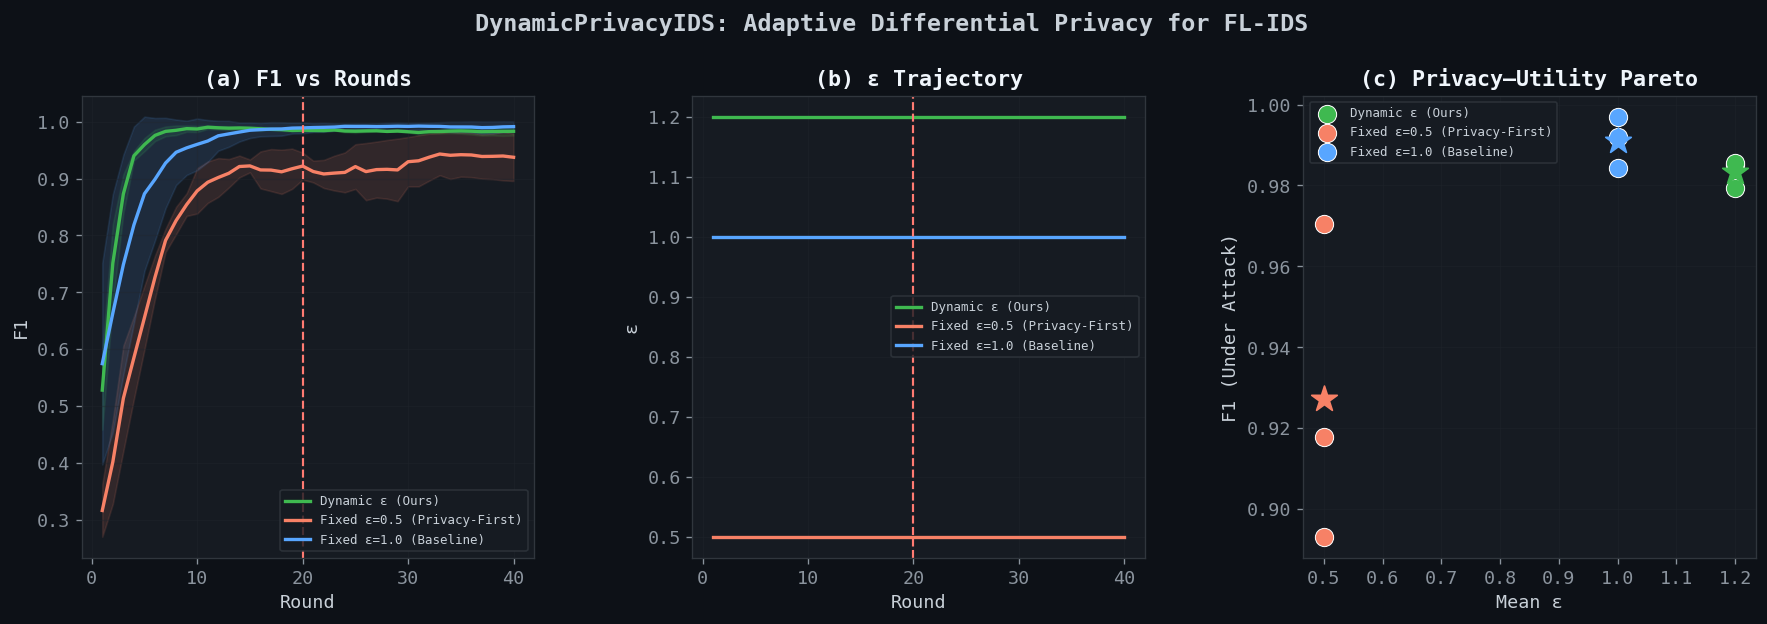

Saved dashboard.png  ← use this for conference slides!


In [9]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: F1 vs rounds ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
for mode, grp in summary.groupby('mode'):
    ax1.plot(grp['round'], grp['f1_mean'], color=PALETTE[mode],
             linewidth=2, label=MODE_LABELS[mode])
    ax1.fill_between(grp['round'],
                     grp['f1_mean'] - grp['f1_std'].fillna(0),
                     grp['f1_mean'] + grp['f1_std'].fillna(0),
                     color=PALETTE[mode], alpha=0.12)
ax1.axvline(x=20, color='#ff7b72', linestyle='--', linewidth=1.3)
ax1.set_xlabel('Round'); ax1.set_ylabel('F1')
ax1.set_title('(a) F1 vs Rounds', fontweight='bold')
ax1.legend(fontsize=7.5); ax1.grid(True, alpha=0.4)

# ── Panel 2: ε trajectory ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
for mode, grp in summary.groupby('mode'):
    ax2.plot(grp['round'], grp['eps_mean'], color=PALETTE[mode],
             linewidth=2, label=MODE_LABELS[mode])
ax2.axvline(x=20, color='#ff7b72', linestyle='--', linewidth=1.3)
ax2.set_xlabel('Round'); ax2.set_ylabel('ε')
ax2.set_title('(b) ε Trajectory', fontweight='bold')
ax2.legend(fontsize=7.5); ax2.grid(True, alpha=0.4)

# ── Panel 3: Pareto ───────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
for mode, grp in pdf.groupby('mode'):
    ax3.scatter(grp['cumulative_eps'], grp['f1_attack'],
                color=PALETTE[mode], s=120, label=MODE_LABELS[mode],
                edgecolors='white', linewidths=0.6, zorder=4)
    ax3.scatter(grp['cumulative_eps'].mean(), grp['f1_attack'].mean(),
                color=PALETTE[mode], s=260, marker='*', zorder=5)
ax3.set_xlabel('Mean ε'); ax3.set_ylabel('F1 (Under Attack)')
ax3.set_title('(c) Privacy–Utility Pareto', fontweight='bold')
ax3.legend(fontsize=7.5); ax3.grid(True, alpha=0.4)

fig.suptitle('DynamicPrivacyIDS: Adaptive Differential Privacy for FL-IDS',
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig(RESULTS_DIR / 'dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved dashboard.png  ← use this for conference slides!')

In [10]:
print('\n📁 Output files:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'   {f}')


📁 Output files:
   results/all_results.csv
   results/dashboard.png
   results/eps_trajectory.png
   results/f1_vs_time.png
   results/metrics_dynamic_seed123.csv
   results/metrics_dynamic_seed42.csv
   results/metrics_dynamic_seed999.csv
   results/metrics_fixed_0.5_seed123.csv
   results/metrics_fixed_0.5_seed42.csv
   results/metrics_fixed_0.5_seed999.csv
   results/metrics_fixed_1.0_seed123.csv
   results/metrics_fixed_1.0_seed42.csv
   results/metrics_fixed_1.0_seed999.csv
   results/pareto.png
   results/summary_table.csv
